# Medidas de posição e dispersão com Python

Instruções iniciais: Faça a limpeza e transformação (verifique os tipos de dados e altere 
se necessário; elimine duplicatas, nulos, brancos e erros) dos dados da tabela “Sales” do 
conjunto de dados “Dados_Sneakers_World3.xlsx”, depois responda aos itens abaixo

b) (15 pontos) Calcule a variância, desvio padrão e coeficiente de variação das variáveis “Sales” (valor das vendas) e “Quantity” (quantidade) e interprete os
resultados. Apresente os resultados em uma tabela (não precisa apresentar o script em Python).

Importação de bibliotecas e base de dados

In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_excel("Dados_Sneakers_World3.xlsx", sheet_name="Sales")

Limpeza e Tratamento dos dados

In [13]:
# Remover linhas vazias
df = df.dropna()

# Remover duplicatas
df = df.drop_duplicates()

In [14]:
# Garantir tipos corretos
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Remover erros após conversão
df = df.dropna(subset=['Sales', 'Quantity'])

SALES

In [15]:
var_sales = np.var(df['Sales'], ddof=0)
std_sales = np.std(df['Sales'], ddof=0)
cv_sales = std_sales / df['Sales'].mean()

QUANTITY

In [16]:
var_quantity = np.var(df['Quantity'], ddof=0)
std_quantity = np.std(df['Quantity'], ddof=0)
cv_quantity = std_quantity / df['Quantity'].mean()

Resultados Obtidos

In [17]:
resultados = pd.DataFrame({
    'Variável': ['Sales', 'Quantity'],
    'Variância': [var_sales, var_quantity],
    'Desvio Padrão': [std_sales, std_quantity],
    'Coef. Variação': [cv_sales, cv_quantity]
})

resultados

,Variável,Variância,Desvio Padrão,Coef. Variação
0,Sales,50012.510860,223.634771,1.346081
1,Quantity,9.223506,3.037022,0.860572


### Analise dos resultados

VARIANCIA: 
- Sales: $50.012,51$ é um número alto, podemos concluir que há flutuações consideráveis nos valores das vendas.
- Quantity: $9,22$ é baixo, isso sujere que o volume de itens por pedido é um pouco mais estável.

DESVIO PADRÂO:
- Sales ($223,63$): As vendas costumam oscilar mais ou menos de $R\$ 223,63$ em torno da média.
- Quantity ($3,03$): A variação na quantidade de itens é de aproximadamente $3$ unidades.

COEFICIENTE DE VARIAÇÃO:
- Sales (1,34): Mostra que existe uma volatilidade muito alta no valor das vendas.Isso torna o processo imprevisível.
- Quantity (0,86): Também apresenta alta volatilidade, mas é menor que a de vendas. Indica que a quantidade de itens por pedido não segue um padrão fixo.

In [18]:
import matplotlib.pyplot as plt
import numpy as np

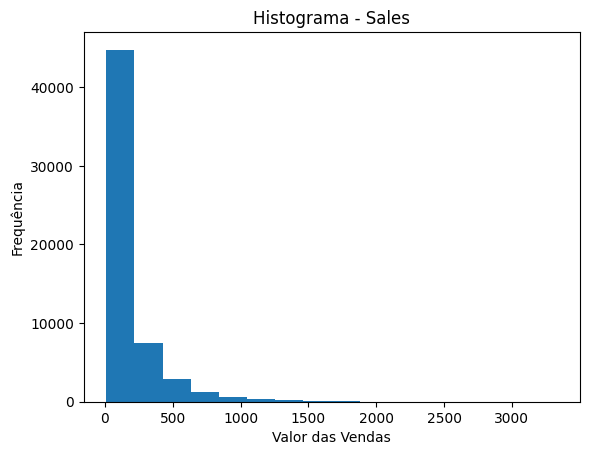

In [19]:
n = len(df['Sales'])
bins = int(1 + np.log2(n))

plt.figure()
plt.hist(df['Sales'], bins=bins)
plt.title("Histograma - Sales")
plt.xlabel("Valor das Vendas")
plt.ylabel("Frequência")
plt.show()

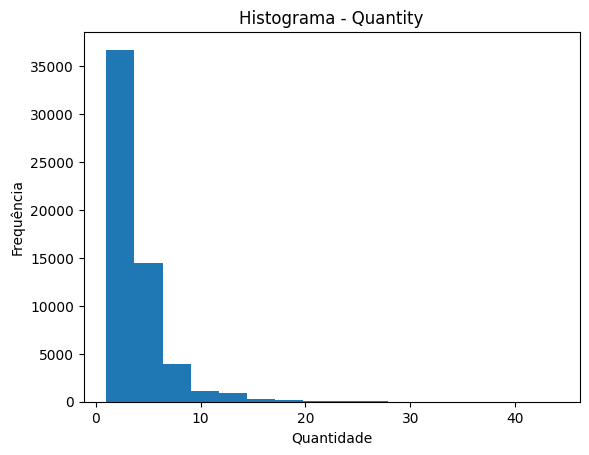

In [20]:
n = len(df['Quantity'])
bins = int(1 + np.log2(n))

plt.figure()
plt.hist(df['Quantity'], bins=bins)
plt.title("Histograma - Quantity")
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.show()